In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("zomato.csv")
print(df.shape)

(51717, 17)


In [4]:
df.head(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [6]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [8]:
df['rate'].dtype

dtype('O')

In [9]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: object

In [10]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [11]:
df['rate'].dtype

dtype('float64')

In [12]:
df['rate'].isnull().sum()

10052

In [13]:
df['rate']= df['rate'].fillna(df['rate'].mean())

In [14]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)

In [15]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'] , errors='coerce')

In [16]:
df['approx_cost(for two people)'].isnull().sum()

346

In [17]:
df['approx_cost(for two people)']= df['approx_cost(for two people)'].fillna(df['approx_cost(for two people)'].mean())

In [18]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                               0
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)        0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [19]:
df['rate'].describe()

count    51717.000000
mean         3.700449
std          0.395391
min          1.800000
25%          3.500000
50%          3.700449
75%          3.900000
max          4.900000
Name: rate, dtype: float64

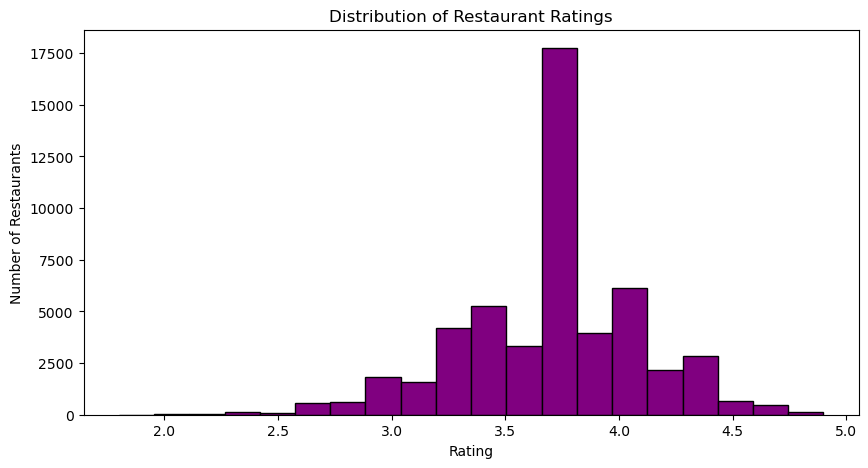

In [25]:
plt.figure(figsize=(10,5))
plt.hist(df['rate'], bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.show()

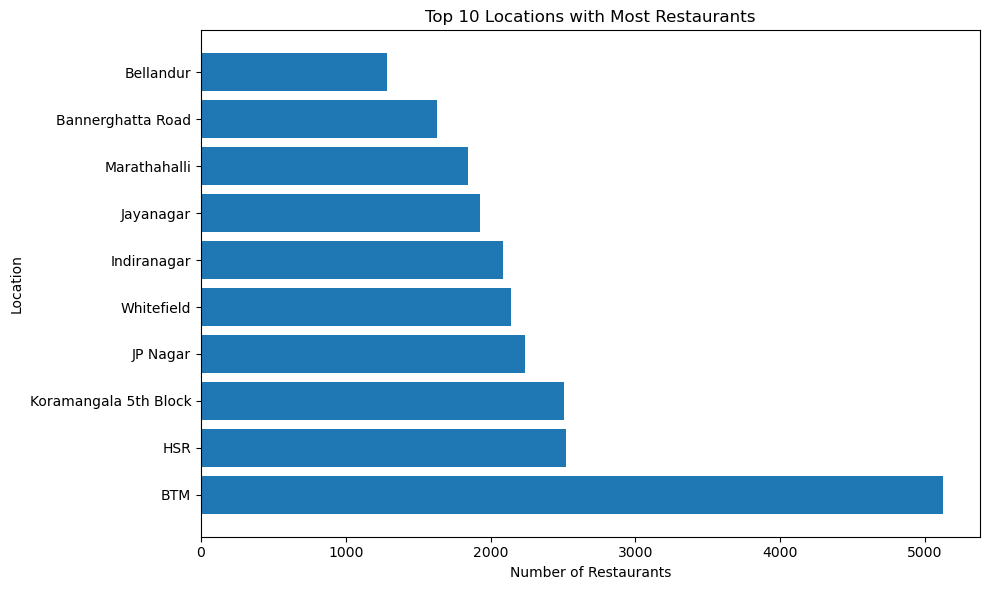

In [30]:
plt.figure(figsize=(10,6))
top_locations = df['location'].value_counts().head(10)
plt.barh(top_locations.index, top_locations.values)
plt.title('Top 10 Locations with Most Restaurants')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

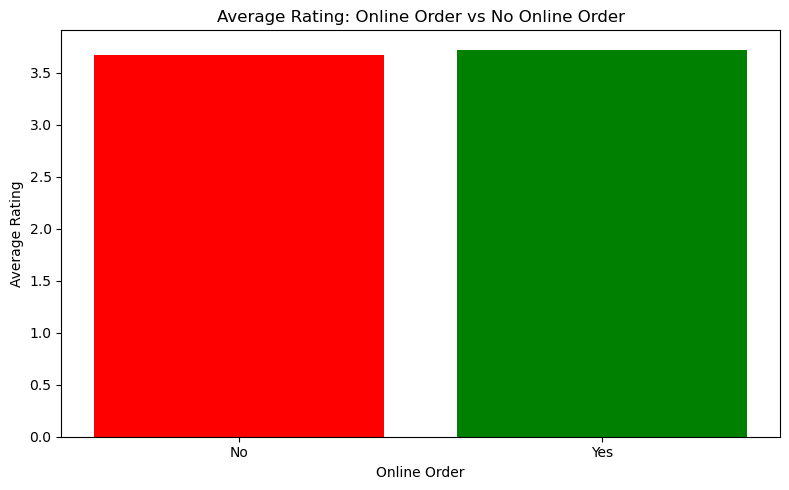

In [33]:
plt.figure(figsize=(8,5))
online_order_rating = df.groupby('online_order')['rate'].mean()
plt.bar(online_order_rating.index, online_order_rating.values, color=['red','green'])
plt.title('Average Rating: Online Order vs No Online Order')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

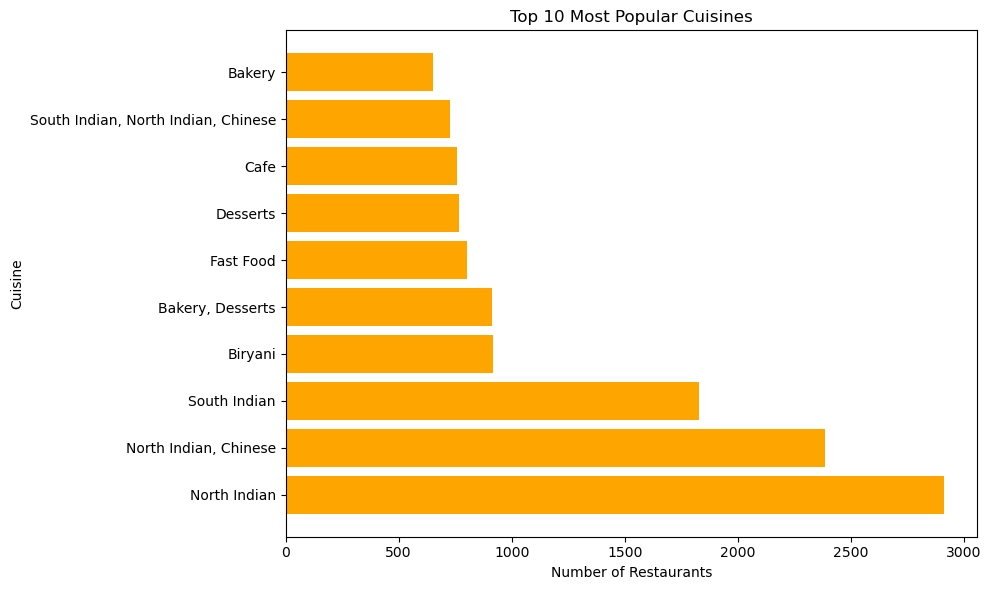

In [34]:
plt.figure(figsize=(10,6))
top_cuisines = df['cuisines'].value_counts().head(10)
plt.barh(top_cuisines.index, top_cuisines.values, color='orange')
plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

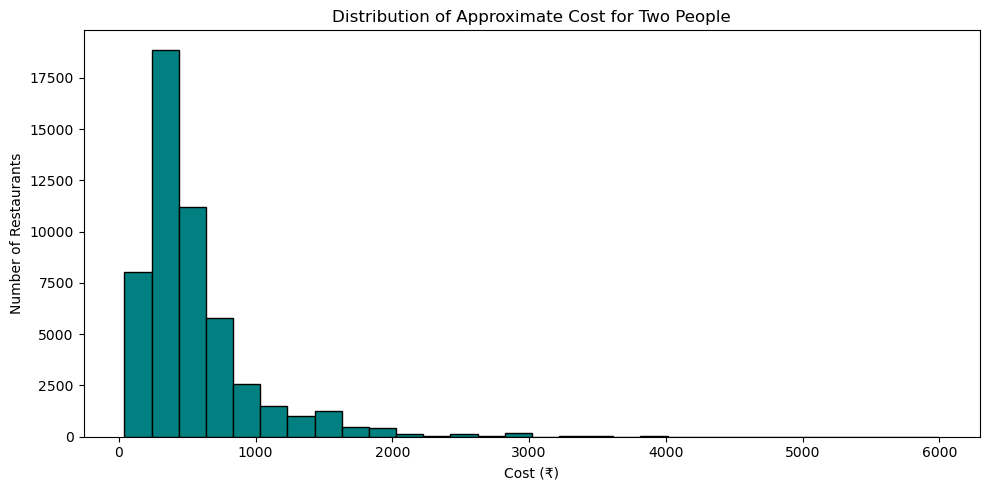

In [35]:
plt.figure(figsize=(10,5))
plt.hist(df['approx_cost(for two people)'], bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Approximate Cost for Two People')
plt.xlabel('Cost (₹)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

In [36]:
print("=" * 50)
print("KEY INSIGHTS FROM ZOMATO BANGALORE ANALYSIS")
print("=" * 50)
print("\n1. Most restaurants have ratings between 3.5 - 4.0")
print("2. BTM Layout has the most restaurants (5000+)")
print("3. Restaurants with online ordering have slightly higher ratings")
print("4. North Indian is the most popular cuisine in Bangalore")
print("5. Most restaurants are budget friendly (₹200-500 for two)")
print("\nDataset: 51,717 restaurants | 17 columns")
print("Tools used: Python, Pandas, NumPy, Matplotlib")

KEY INSIGHTS FROM ZOMATO BANGALORE ANALYSIS

1. Most restaurants have ratings between 3.5 - 4.0
2. BTM Layout has the most restaurants (5000+)
3. Restaurants with online ordering have slightly higher ratings
4. North Indian is the most popular cuisine in Bangalore
5. Most restaurants are budget friendly (₹200-500 for two)

Dataset: 51,717 restaurants | 17 columns
Tools used: Python, Pandas, NumPy, Matplotlib
